In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

# 1. Car price prediction project

The intention here is to build a model that predicts the price of a car.

In this first unit we look at the scenario, the dataset we will use, the plan for the project and where che code and the data live.

## The dataset

To train a model we need data, and we use a dataset with car prices from Kaggle.

It has different characteristics of cars - the make (the manifacturer), the model, the year, the engine type, the fuel type and other properties.
 - Every row is one car and every column is one characteristic of that car.
 - The idea is to use all the features to predict the column "MSRP" (Manifacturer Suggested Retail Price).

# 2. Data preparation

Now we take the car price dataset and prepare it for machine learning: we download it, load it with pandas, and make the column names and the string values consistent.

## Getting and loading the data

In [2]:
df = pd.read_csv('/workspaces/ZoomML_Homeworks/02_regression/data.csv')
len(df)

11914

In [3]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## Making the column names consistent

Looking at the columns names, sometimes there are uppercase letters, spaces or few underscores.
- The idea is to make everything lowercase and replace spaces with underscores

In [4]:
df.columns.str.lower() #rende minuscole tutte le stringhe contenute negli indici delle colonne 

Index(['make', 'model', 'year', 'engine fuel type', 'engine hp',
       'engine cylinders', 'transmission type', 'driven_wheels',
       'number of doors', 'market category', 'vehicle size', 'vehicle style',
       'highway mpg', 'city mpg', 'popularity', 'msrp'],
      dtype='str')

In [5]:
df.columns.str.lower().str.replace(' ', '_') #rimpiazzo gli spazi vuoti tra le stringhe con l'underscore

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [6]:
df.columns = df.columns.str.lower().str.replace(' ', '_') #abbiamo ridefinito le colonne con le modifiche appena fatte

In [7]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## Finding the string columns

The values have the same problem, so let's normalize the string values the same way.
- First we find out which columns are strings
- Secondly we select them and create a list

In [8]:
df.dtypes #indica che tipi ci sono in ogni colonna

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [9]:
df.dtypes[df.dtypes == 'str'] #seleziono le colonne che hanno tipo "string"

make                 str
model                str
engine_fuel_type     str
transmission_type    str
driven_wheels        str
market_category      str
vehicle_size         str
vehicle_style        str
dtype: object

In [10]:
strings = list(df.dtypes[df.dtypes == 'str'].index) #creo una lista con solo gli indici delle colonne che hanno stringhe come valori
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

## Normalizing the string values

Nw that we have all the string column names, we loop over them and apply the same transformation we used for the column names:

In [11]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_') #ho trasformato tutti i valori stringhe delle colonne in stringhe minuscole e con underscore

In [12]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


# 3. Exploratory data analysis (EDA)

Now we look at every column, see what kind of values are there, and try to get a feeling for the data and the problem before training a model.

## Look at every column

To see what's inside each column, we iterate over all columns and print some statistics for every one: the column name, a few values and the number of unique values.

In [13]:
for col in df.columns:
    print(col)                          #stampa nome colonna
    print(df[col].unique()[:5])         #stampa i primi 5 valori distinti presenti nella colonna
    print(df[col].nunique())            #stampa quanti valori distinti ci sono nella colonna
    print()                             #riga vuota per rendere l'output più leggibile

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

## Distribution of price
We want to see the distribution of prices using histograms:

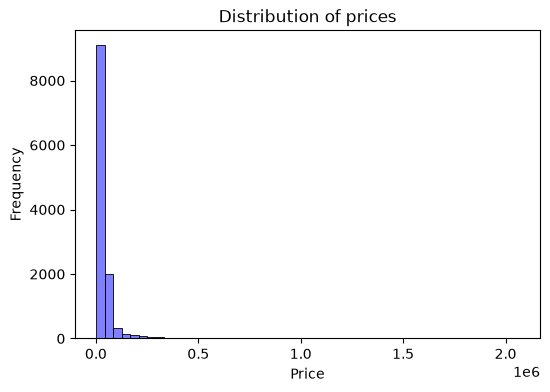

In [14]:
plt.figure(figsize=(6, 4))

sns.histplot(df.msrp, bins=50, color='blue', alpha=0.5)
plt.ylabel('Frequency')
plt.xlabel('Price')
plt.title('Distribution of prices')

plt.show()

This is a *long-tail* distribution: most of the data sits in one place, and a shallow tale stretches far to the right.
To see the shape better, we zoom in on prices below 100,000:

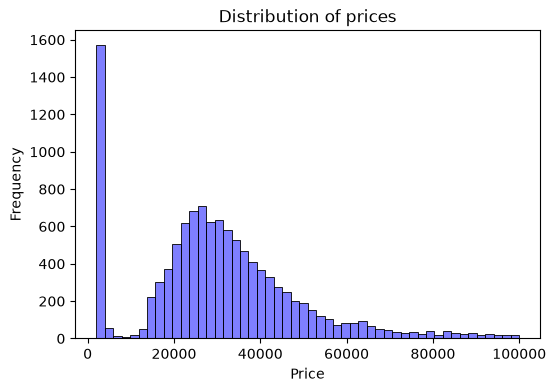

In [15]:
plt.figure(figsize=(6, 4))

sns.histplot(df.msrp[df.msrp < 100000], bins=50, color='blue', alpha=0.5)
plt.ylabel('Frequency')
plt.xlabel('Price')
plt.title('Distribution of prices')

plt.show()

## Removing the long tail with a logarithm

The long-tail is not good for Machine Learning, because it will confuse the model and screw things up.
So the usual trick is to apply the logarithm to the price, which compresses large values.

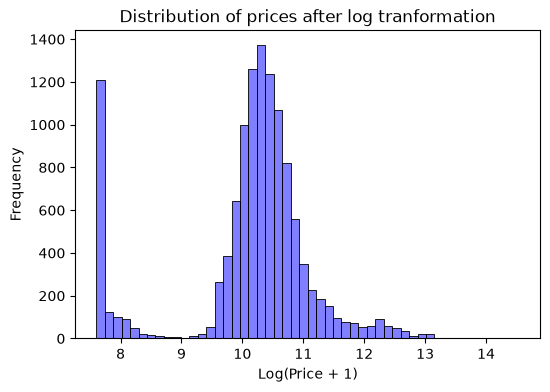

In [16]:
log_price = np.log1p(df.msrp)                                   #in NumPy log1p adds one to every value, and then takes the logarithm

plt.figure(figsize=(6, 4))

sns.histplot(log_price, bins=50, color='blue', alpha=0.5)
plt.ylabel('Frequency')
plt.xlabel('Log(Price + 1)')
plt.title('Distribution of prices after log tranformation')

plt.show()

This situation is ideal for models: models do much better when the target variable looks like a *normal* distribution than with long-tail ones.

## Missing values

To count how many missing values there are, we use *isnull()*: for every cell it says whether the value in this cell is missing or not. In this form it is not super useful, so we follow it with *sum()*, which sums across every column and tells us the number of missing values in each:

In [17]:
df.isnull()                 #mostra quali valori mancano in ciascuna colonna (True) e quali no (False)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11910,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11911,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11912,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [18]:
df.isnull().sum()           #conta quanti valori mancano in ciascuna colonna

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

# 4. Setting up the validation framework

The dataset is cleaned and explored, so now we set up the validation framework: we split the data into train, validation and test parts, and prepare the target variable for each part.

## Train, validation and test

- Now we take the dataset and we split it into three parts (training, validation and test sets).
- We train a model, check if it works fine on the validation dataset and leave the test dataset alone.
- Then, from each of these parts we create a feature matrix $X$ and the target variable $y$.

![tvt](/workspaces/ZoomML_Homeworks/02_regression/images/04_validation_framework_01_train_val_test_split_crisp.jpg)


## Calculating the sizes of the parts

- We will do a 60/20/20 split, so we first need to calculate how many records 20% actually is. 
- Our dataframe has almost 12,000 records, so 20% of that is approximately 2,400. 
- We want a whole number of records, not a fraction like 2382.8, so we cut the fraction off with *int()*:

In [19]:
n = len(df)
n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)

n, n_val, n_test, n_train

(11914, 2382, 2382, 7150)

## Taking a part of the dataframe with iloc

Now we know the sizes, and we need to take a part of the dataframe of that size. For that we use *iloc* and get the first ten records:

In [20]:
df.iloc[:10]        #prende i primi 10 valori

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200
6,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,26,17,3916,44100
7,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39300
8,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,36900
9,bmw,1_series,2013,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,27,18,3916,37200


Now we cut the dataframe sequentially:

In [21]:
df_train = df.iloc[:n_train].copy()
df_val = df.iloc[n_train:n_train+n_val].copy()
df_test = df.iloc[n_train+n_val:].copy()

But in this dataset there is some order, so in general it's a good idea to shuffle the data.

## Shuffling the records

In *iloc* we can pass an arbitrary sequence of numbers and it will return the rows in that order.

Now we take the numbers from 0 to n-1, reshuffle them and then take the first 20% of the shuffled numbers for validation etc.

In [22]:
np.random.seed(2)       #rendo risultato riproducibile
idx = np.arange(n)      #genera la sequenza di numeri
np.random.shuffle(idx)  #prende la sequenza di numeri e la mischia

In [23]:
df_train = df.iloc[idx[:n_train]].copy()
df_val = df.iloc[idx[n_train:n_train+n_val]].copy()
df_test = df.iloc[idx[n_train+n_val:]].copy()

## Resetting the index

In [24]:
len(df_train), len(df_val), len (df_test)

(7150, 2382, 2382)

Looking at *df_train*, we see that the index now contains the original row numbers - 2735, 6720 and so on, in random order. 

Sometimes it is inconvenient: we don't really need to know what the original index of each record was. So we reset the index and reassign the result back to the dataframe. We pass drop=True because we don't need the old index as a column:

In [25]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

## Preparing *y* and removing *msrp*

The dataframes will be used to make the feature matrix *X*, the target *y* comes from the msrp column, and we already know that we need to apply the log1p transformation to it because of the long tail in its distribution. 

Instead of keeping a pandas series, we immediately take its values with .values to get a NumPy array - we don't need the indexes and other pandas things for *y*:

In [26]:
y_train_orig = df_train.msrp.values
y_val_orig = df_val.msrp.values
y_test_orig = df_test.msrp.values

y_train = np.log1p(y_train_orig)
y_val = np.log1p(y_val_orig)
y_test = np.log1p(y_test_orig)

In [27]:

del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

We delete it because we might accidentally use it. If the price gets into the features, we will use the price to predict the price - and of course the model will be perfect. Then we might spend a lot of time figuring out what is wrong. This happened to me many times, so after splitting the data I always take the target out into a separate variable and delete it from the dataframe completely.

# 5. Linear Regression

In this lesson we look at linear regression, the model we use for solving regression problems - problems where we predict a number, like the price of a car. We derive the formula, implement it in Python for one car, and see what the prediction is made of.

## The formula for one car

A car can be a row in our feature matrix, so we can think of it as a vector of $n$ elements: $x_{i1}, \dots, x_{in}$.

We want a function that takes all these features and produces something close to the price: g(xi) ≈ yi

## The linear regression formula

We need to combine these values in a way that gives us something close to the price. The formula for linear regression is:
\begin{equation} g(x_i)=w_0+w_1\cdot x_{i1}+w_2\cdot x_{i2}+\dots+w_n\cdot x_{in} = w_0 + \sum_{j=1}^n w_j\cdot x_{ij} \end{equation}

where $w_0$ is the bias term - the prediction we make without knowing anything about the car.

## Implementing it in Python

In this case we have the feature vector $x_i$, the bias term $w_0$ and the vector $w$ with a weight for each feature:

In [28]:
xi = [453, 11, 86]
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [29]:
def linear_regression(xi):
    n = len(xi)
    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

## From log price back to dollars

The prediction is not the price in dollars: we applied the log1p transformation to $y$  beacuse of the long tail in the price distribution, so our model predicts the logarithm of the price.
- To undo the logarithm we need the exponent:

In [30]:
linear_regression(xi)

12.312

In [31]:
np.expm1(12.312)

np.float64(222347.2221101062)

So our prediction for this car is about 222 dollars.

# 6. Linear Regression: vector form

Last time we implemented linear regression for a single car. Now we generalize it: first to a dot product for one car, then to a matrix-vector multiplication that produces predictions for all the cars in the dataset at once.

## The dot product

If we look at the formula for a single car, in particular at the sum, we can see that it is simply a dot product - a vector-vector multiplication, so let's rewrite the formula:
\begin{equation} g(x_i)=w_0+\sum_{j=1}^n x_{ij}\cdot w_j = w_0 +x_i^{\text{T}}w \end{equation}

In [32]:
def dot(xi,w):
    n = len(xi)
    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res

Now the linear regression function becomes short - it just adds the bias term to the dot product between the features and the weights:

In [33]:
def linear_regression(xi):
    return w0 + dot(xi,w)

## The fictional feature

We can bring the bias term inside the dot product, imagining that there is an extra feature of our car $x_{i0}$ and this feature is always 1.

In [35]:
w_new = [w0] + w
w_new

[7.17, 0.01, 0.04, 0.002]

In [36]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi,w_new)

In [37]:
linear_regression(xi)

12.312

## Linear regression for all cars

Consider now all the $m$ cars in the dataset, so now we have the matrix $X$ with $m$ rows and $n+1$ columns.

We take three cars and prepend 1 to each feature vector, then put them together into a matrix - a list of lists - and turn it into a two-dimensional NumPy array:

In [38]:
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = [x1, x2, x10]
X = np.array(X)

The weights vector is the same $w_{new}$ as before:

In [ ]:
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

And now all we need to do is multiply this matrix with this vector. NumPy arrays have a dot method for that:

In [39]:
def linear_regression(X):
    return X.dot(w_new)

linear_regression(X)

array([12.38 , 13.552, 12.312])

In [41]:
np.expm1([12.38 , 13.552, 12.312])

array([237992.82334859, 768348.51018973, 222347.22211011])

# 7. Training linear regression: Normal equation

Where do the weights come from? We derive the **normal equation**, a closed-form formula for the weights:
\begin{equation} w = \left(X^{\text{T}}X\right)^{-1} X^{\text{T}}y \end{equation}

## Implementing the normal equation

In [46]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)

In [48]:
XTX = X.T.dot(X)     
XTX_inv = np.linalg.inv(XTX)   
XTX_inv

array([[ 2.35803616e-06, -1.46900642e-05,  8.00007928e-09],
       [-1.46900642e-05,  2.94487947e-04, -3.84130606e-06],
       [ 8.00007928e-09, -3.84130606e-06,  2.28083884e-07]])

In [49]:
y = [100, 200, 150, 250, 100, 200, 150, 250, 120]

In [ ]:
w_full = XTX_inv.dot(X.T).dot(y)        
w_full

array([0.26190562, 3.06101252, 0.03696909])

Define now a complete function where we implement also the bias term in the feature matrix:

In [ ]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])              #creiamo una colonna di 1 con indice 0
    X = np.column_stack([ones, X])          #aggiungiamo la colonna dei bias   

    XTX = X.T.dot(X)                        #Gram matrix 
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)             #Normal equation    
    
    return w[0], w[1:]

# 8.Baseline model for car price prediction project

## Selecting the base features

Let's remind ourselves which columns the training dataframe has:

In [ ]:
df_train.columns

Because linear regression works only with numbers, for the baseline we pick the numerical columns and put them in a list:

In [ ]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

To get a subset of columns from a dataframe, we select the columns with this list and take the values as a NumPy array:

In [ ]:
X_train = df_train[base].values

## Dealing with missing values

If we train the model and the outputs give "nan", we come back to the training feature matrix and fill the columns with nan values with zeros or other:

In [ ]:
X_train = df_train[base].fillna(0).values

## Training the model

Now the feature matrix has no missing values, and training finishes:

In [ ]:
w0, w = train_linear_regression(X_train, y_train)

## Comparing the predictions with the actual prices

Now we can apply the trained model to the training data. We use matrix multiplication, adding the bias term separately:

In [ ]:
y_pred = w0 + X_train.dot(w)

To see how good the predictions are, let's plot them as a histogram and compare with the histogram of the actual target values. We use the same histplot function from seaborn that we used during exploratory data analysis:

In [ ]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

Looking at the chart, the distribution of predictions does not really match the distribution of actual values: the red peak sits to the left of the blue one, so in many cases the model predicts a value smaller than the actual price.

Just by looking at this chart we suspect the model is not ideal, but that is not an objective way to say it. And when we start improving the model, we want to be sure that it indeed improved. For that we need a single number that quantifies how good or bad the model is. That is exactly what we will do in the next unit with RMSE.

# 9.Root Mean Squared Error (RMSE)

In this unit we learn one way of quantifying how good or bad a regression model is: root mean squared error, or RMSE.

## Implementation

The function takes the vector of actual values and the vector of predictions:

In [ ]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

Now let's use it to evaluate our baseline model. We already have the predictions *y_pred* on the training set:

In [ ]:
rmse(y_train, y_pred)

This single number is much easier to work with than a chart: whenever we change something - add a feature, transform a variable, try a different model - we recompute it. If the number goes down, the model got better.

# 10. Computing RMSE on validation data

Previously we measured RMSE on the training data - the same data the model learned from. Here we fix that and evaluate the model the way it should be evaluated: on the validation data.

In [ ]:
#modo carino per definire la feature matrix 
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

Now we can train the model and validate it:
1. We prepare the matrix from the *training* dataframe and train the model. 
2. We prepare the *validation* matrix with the same function, apply the model, and compute the RMSE between the actual target values and our predictions:

In [ ]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

The number is pretty similar to what we had on the training data. That is what we want to see: the model behaves on unseen data about as well as on the data it learned from.

Looking at the code, we can see the two parts clearly:

- The training part only touches the training dataset: we prepare the matrix and learn the weights.
- The validation part prepares the validation dataset in the same way as the training dataset, then applies the model learned in the previous step, and computes the root mean squared error for that model.

Now we have a way of evaluating the quality of our model using the root mean squared error on the validation dataset. This also means we can check whether a change actually improves the model

# 11.Feature engineering

This is the process of creating new features from the one we already have. Here we create our first new feature - the age of a car - and see it improve the RMSE of our model quite a bit. 

## From year to age

Let's take a look again at our training dataset: one of the columns there is *year*, and we know this is one of the most important variables for predicting the price of a car: if a car is old, it is usually cheaper, and if it is new, it is more expensive.

Instead of using the year as it is, we can compute the age of a car. For that we need to know when this data was collected - it turns out it was collected in 2017. So "now" is 2017, and the age is simply 2017 - year. Some of the cars are 0 years old, some are 9, some are 26:

In [ ]:
2017 - df_train.year

## Adding the age feature to prepare_X

In [ ]:
def prepare_X(df):
    df = df.copy()
    df['age'] = 2017 - df.year
    features = base + ['age']

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

## Checking the improvement

In [ ]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression(X_train, y_train)

y_pred = w_0 + X_train.dot(w)
print('train', rmse(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation', rmse(y_val, y_pred))

In [ ]:
plt.figure(figsize=(6, 4))

sns.histplot(y_val, label='target', color='#222222', alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color='#aaaaaa', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('Log(Price + 1)')
plt.title('Predictions vs actual distribution')

plt.show()

# 12. Categorical variables

Categorical variables are variables that contain categories instead of numbers. In this unit we add them to our car price model and see that one of them breaks it completely - which is exactly the problem the next unit solves.

So far we only used numerical features. But the dataset has quite a few categorical variables - variables that are categories. 
- They are typically strings: make, model, engine_fuel_type, transmission_type, driven_wheels and others.

There is one variable that looks numerical but is not: *number_of_doors*. It contains 2, 3 and 4 - numbers - but these numbers are distinct categories of cars: cars with two doors, cars with three doors and cars with four doors are quite different. It just happened that the values of this variable are numbers, and that's why pandas treats them as usual numbers.

## Encoding categories as binary columns

ML models can only work with numbers, so we need to encode categorical variables. 

The typical way of doing it: for each value of the column, we create a separate *binary column*. 
- If our column contains the values 2, 3, 4 and 2 again, we represent it with three columns - one for each door count - and put 1 in the column that matches the row, and 0 everywhere else.
- To create the columns, we can write a loop over the values [2, 3, 4] and use a string template for the name, so that each value gets its own column:

In [ ]:
for v in [2,3,4]:
    df_train['num_doors_%s' % v] = (df_train.number_of_doors == v).astype('int')

## Adding doors to prepare_X

In [ ]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

We validate the model with the same code as before:

In [ ]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

## Adding the make

But I'm pretty sure that make should be quite useful. 

If we look at the values of this column, there are a lot of them - 48 unique makes. We can take the most popular ones with value_counts:

In [ ]:
df['make'].value_counts().head(5)

The output shows the counts, and the names themselves are in the index, so we wrap it in a list:

In [ ]:
makes = list(df.make.value_counts().head().index)

This gives us the five most popular makes of cars: chevrolet, ford, volkswagen, toyota and dodge. We can include them in the same way as the number of doors - one binary column per make:

In [ ]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        feature = 'num_doors_%s' % v
        df[feature] = (df['number_of_doors'] == v).astype(int)
        features.append(feature)

    for v in ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']:
        feature = 'is_make_%s' % v
        df[feature] = (df['make'] == v).astype(int)
        features.append(feature)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [ ]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression(X_train, y_train)

y_pred = w_0 + X_train.dot(w)
print('train:', rmse(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation:', rmse(y_val, y_pred))

## Doing the same for all the categorical variables

In [ ]:
df['engine_fuel_type'].value_counts()

In [ ]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')
    
    for v in [2, 3, 4]:
        feature = 'num_doors_%s' % v
        df[feature] = (df['number_of_doors'] == v).astype(int)
        features.append(feature)

    for v in ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']:
        feature = 'is_make_%s' % v
        df[feature] = (df['make'] == v).astype(int)
        features.append(feature)

    for v in ['regular_unleaded', 'premium_unleaded_(required)', 
              'premium_unleaded_(recommended)', 'flex-fuel_(unleaded/e85)']:
        feature = 'is_type_%s' % v
        df[feature] = (df['engine_fuel_type'] == v).astype(int)
        features.append(feature)
        
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [ ]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression(X_train, y_train)

y_pred = w_0 + X_train.dot(w)
print('train:', rmse(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation:', rmse(y_val, y_pred))

In [ ]:
df['transmission_type'].value_counts()

In [ ]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')
    
    for v in [2, 3, 4]:
        feature = 'num_doors_%s' % v
        df[feature] = (df['number_of_doors'] == v).astype(int)
        features.append(feature)

    for v in ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']:
        feature = 'is_make_%s' % v
        df[feature] = (df['make'] == v).astype(int)
        features.append(feature)

    for v in ['regular_unleaded', 'premium_unleaded_(required)', 
              'premium_unleaded_(recommended)', 'flex-fuel_(unleaded/e85)']:
        feature = 'is_type_%s' % v
        df[feature] = (df['engine_fuel_type'] == v).astype(int)
        features.append(feature)

    for v in ['automatic', 'manual', 'automated_manual']:
        feature = 'is_transmission_%s' % v
        df[feature] = (df['transmission_type'] == v).astype(int)
        features.append(feature)
        
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [ ]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression(X_train, y_train)

y_pred = w_0 + X_train.dot(w)
print('train:', rmse(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation:', rmse(y_val, y_pred))

In [ ]:
df['driven_wheels'].value_counts()

In [ ]:
df['market_category'].value_counts().head(5)

In [ ]:
df['vehicle_size'].value_counts().head(5)

In [ ]:
df['vehicle_style'].value_counts().head(5)

In [ ]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')
    
    for v in [2, 3, 4]:
        feature = 'num_doors_%s' % v
        df[feature] = (df['number_of_doors'] == v).astype(int)
        features.append(feature)

    for v in ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']:
        feature = 'is_make_%s' % v
        df[feature] = (df['make'] == v).astype(int)
        features.append(feature)

    for v in ['regular_unleaded', 'premium_unleaded_(required)', 
              'premium_unleaded_(recommended)', 'flex-fuel_(unleaded/e85)']:
        feature = 'is_type_%s' % v
        df[feature] = (df['engine_fuel_type'] == v).astype(int)
        features.append(feature)

    for v in ['automatic', 'manual', 'automated_manual']:
        feature = 'is_transmission_%s' % v
        df[feature] = (df['transmission_type'] == v).astype(int)
        features.append(feature)

    for v in ['front_wheel_drive', 'rear_wheel_drive', 'all_wheel_drive', 'four_wheel_drive']:
        feature = 'is_driven_wheens_%s' % v
        df[feature] = (df['driven_wheels'] == v).astype(int)
        features.append(feature)

    for v in ['crossover', 'flex_fuel', 'luxury', 'luxury,performance', 'hatchback']:
        feature = 'is_mc_%s' % v
        df[feature] = (df['market_category'] == v).astype(int)
        features.append(feature)

    for v in ['compact', 'midsize', 'large']:
        feature = 'is_size_%s' % v
        df[feature] = (df['vehicle_size'] == v).astype(int)
        features.append(feature)

    for v in ['sedan', '4dr_suv', 'coupe', 'convertible', '4dr_hatchback']:
        feature = 'is_style_%s' % v
        df[feature] = (df['vehicle_style'] == v).astype(int)
        features.append(feature)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [ ]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression(X_train, y_train)

y_pred = w_0 + X_train.dot(w)
print('train:', rmse(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation:', rmse(y_val, y_pred))

In [ ]:
w_0

We execute the same validation code again, and now the value is significantly higher than what we had before. Before we had 0.5, and now all of a sudden it's 41.

Something went wrong. If we look at the weights that our train_linear_regression function outputs, they are huge - some of them are around 10 to the power of 15. We wanted to improve our model by adding more variables, but we just made it worse.

# 13.Regularization

In the normal equation, sometimes the inverse of Gram matrix doesn't exist.

- It usually happens when the feature matrix has duplicate columns.
- In our case, the reason is that real data is usually not super clean: there are sometimes mistakes in the writing, so when we calculate the inverse, the result is a huge number.

## Controlling the weights with regularization

To solve this problem, we can add a small number to the diagonal of the matrix, so that the inverse can still be found and the numbers in it are much more under control.
- The larger the number we add to the diagonal, the more control we get over the weights.
- This works because by adding something to the diagonal, we make sure that it is less possible that one column is a duplicate of another.

To add only a small number, we multiply the identity matrix by that number first:

In [ ]:
XTX = XTX + 0.01 * np.eye(3)        #np.eye(3) è un esempio

## The regularized training function

With that, we can go back to our function for training linear regression and slightly change it. We'll call it *train_linear_regression_reg*, and it gets one more parameter - *r*, short for regularization:

In [ ]:
def train_linear_regression_reg(X, y, r = 0.01):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

Let's take the code from the previous unit and replace the training function with this new one, using r=0.01: the result is not only much better than the 41 we got with the non-regularized version - it is also better than what we had before adding all the categorical variables.

*r* is a parameter: if we set it too high, the model becomes worse, and if we set it to 0, we are back to the usual linear regression. So now we need to find the best value for *r*.

# 14. Tuning the model

Tuning the model means finding the best value for this parameter *r* - and the validation set is exactly the tool for that.

In [ ]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    print(r, w0, score)

What we see: 
1. For zero regularization the bias term is huge and the RMSE is huge too - 266. That is the broken model with the duplicated columns problem. 
2. But for even a little bit of regularization it improves immediately, and after that the score doesn't really change that much. 
3. It starts to become a bit worse as we increase the regularization, and when it's 10 it's even worse.

Looking at the bias term, the more regularization we add, the smaller it is. It looks like maybe 0.001 is a good value, because the model hasn't started to degrade in performance there, and it's not too large. 

To be honest, it doesn't really matter here - it could be this one or the one next to it. 

We can just go with 0.001 and we saw that it works on the validation set.

# 15.Using the model

In this unit we train the final model, check it on the test data, and then use it the way it would be used in practice: to predict the price of a single car.

## Training the final model

For the final model we do something different: we combine the training and validation datasets into one - let's call it *full_train* - train the model on all of it, and then make the final evaluation on the test dataset.

In [ ]:
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.rest_index(drop = True)       #now it's sequential

y_full_train = np.concatenate([y_train, y_val])

In [ ]:
X_full_train = prepare_X(df_full_train)

In [ ]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

To check the final model, we prepare the test dataset exactly in the same way as we did the validation dataset - we just replace validation with test:

In [ ]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

The RMSE is almost the same as on validation - equal up to the third decimal point.

That is a very good sign. It means our model generalizes well: it didn't get this score just by chance.

## Predicting the price of a car

We can take any car from the test dataset and pretend it's a new car:

In [ ]:
car = df_test.iloc[20].to_dict()        #this gives us a dictionary with all the informations about the car
car

We create a small dataframe with a single row - pandas can create a dataframe from a list of dictionaries, and our list contains just the one car from the request:

In [ ]:
df_small = pd.DataFrame([car])
X_small = prepare_X(df_small)

Then we apply the model to this feature matrix with one row:

In [ ]:
y_pred = w0 + X_small.dot(w)
y_pred = y_pred[0]
y_pred

There is just one single car, so we take the first number of the array. 

And remember: this is the logarithm of the price, not the price itself. To undo the logarithm, we take the exponent:

In [ ]:
np.expm1(y_pred)

Let's see how much this car costs:

In [ ]:
np.expm1(y_test[20])